In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from tqdm import tqdm 

%run 01_vqvae.ipynb
%run 03_transformer.ipynb

input:  torch.Size([4, 1, 28, 28])
x_hat: torch.Size([4, 1, 28, 28])
z_e: torch.Size([4, 32, 7, 7])
z_q: torch.Size([4, 32, 7, 7])
idx: torch.Size([4, 7, 7])
using mps
torch.Size([4, 49, 512])


In [8]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'using {device}')

using mps


In [3]:
vqvae = VQVAE(K=512, d=32).to(device)
vqvae.load_state_dict(torch.load('../data/vqvae_mnist.pt', map_location=device))
vqvae.eval()

gpt       = GPT(K=512, S=7, d_model=128, nhead=4, num_layers=6).to(device)
gpt.load_state_dict(torch.load('../data/gpt_mnist.pt', map_location=device))
gpt.eval()

vqvae, gpt

using mps


(VQVAE(
   (enc): Encoder(
     (conv1): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
     (conv2): Conv2d(32, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
     (act): ReLU()
   )
   (vq): VectorQuantizer()
   (dec): Decoder(
     (convt1): ConvTranspose2d(32, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
     (convt2): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
     (act): ReLU()
   )
 ),
 GPT(
   (token_emb): Embedding(512, 128)
   (label_emb): Embedding(10, 128)
   (transformer): TransformerEncoder(
     (layers): ModuleList(
       (0-5): 6 x TransformerEncoderLayer(
         (self_attn): MultiheadAttention(
           (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
         )
         (linear1): Linear(in_features=128, out_features=2048, bias=True)
         (dropout): Dropout(p=0.1, inplace=False)
         (linear2): Linear(in_features=2048, out_features=128, bias=True)


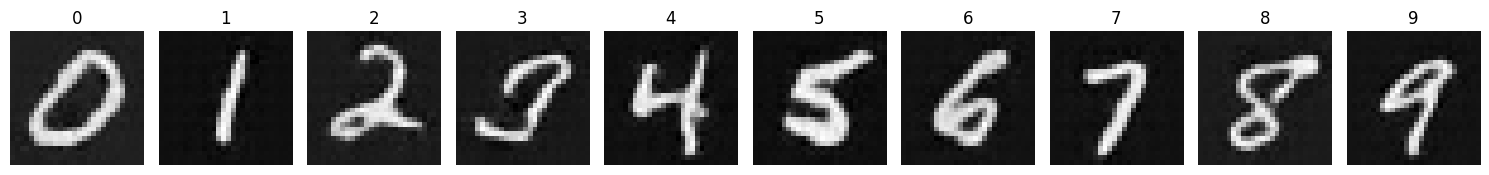

In [62]:
S = 7
d = 32

@torch.no_grad()
def generate(labels):
    # labels: (B)
    B = labels.shape[0]
    x = torch.cat([labels.view(B, 1), torch.zeros(B, S*S, dtype=torch.long, device=device)], dim=1) # (B, S*S+1)
    for i in range(S*S):
        logits = gpt(x[:, :-1]) # (B, S*S, K)
        logits = logits[:, i, :] # (B, K)
        probs = nn.functional.softmax(logits, dim=1) # (B, K)
        next_tokens = torch.multinomial(probs, 1)
        x[:,i+1] = next_tokens.squeeze()

    z_q = vqvae.vq.codebook[x[:,1:]] # (B, S*S, d)
    z_q = z_q.transpose(1, 2).contiguous().view(B, d, S, S)
    out = vqvae.dec(z_q)
    return out
    
labels = torch.arange(10, dtype=torch.long, device=device)
images = generate(labels)

fig, axes = plt.subplots(1, 10, figsize=(15, 5))
for ax, img, label in zip(axes.flat, images, labels):
    ax.imshow(img.cpu().squeeze(), cmap='gray')
    ax.set_title(str(label.item()))
    ax.axis('off')
plt.tight_layout()
plt.show()

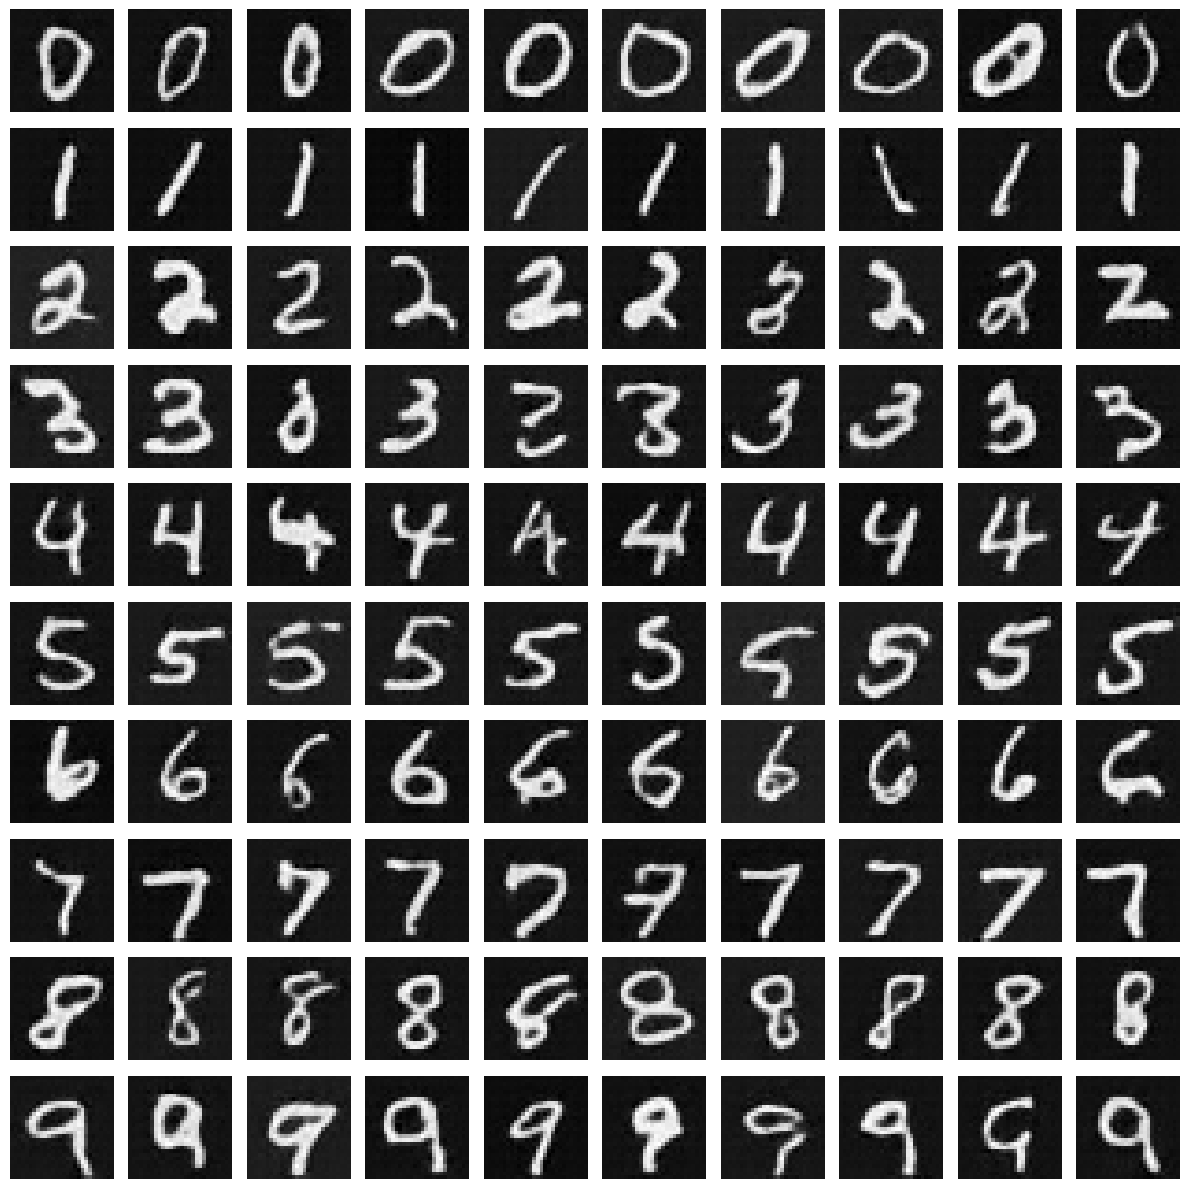

In [64]:
n_samples = 10
all_images = []
for digit in range(10):
    labels = torch.full((n_samples,), digit, dtype=torch.long, device=device)
    imgs = generate(labels)  # (10, 1, 28, 28)
    all_images.append(imgs.cpu())

fig, axes = plt.subplots(10, 10, figsize=(12, 12))
for row in range(10):
    for col in range(10):
        ax = axes[row, col]
        ax.imshow(all_images[row][col].squeeze(), cmap='gray')
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(str(row), fontsize=10, rotation=0, labelpad=12, va='center')
plt.tight_layout()
plt.show()